# 03 – Model Training & Evaluation

**Project:** Area Feasibility Scoring Model  
**Goal:** Train and compare a logistic regression baseline and a Random Forest model to predict area affordability.

---
### Contents
1. Setup
2. Data Preparation & Train/Test Split
3. Pipeline Construction (leakage-safe)
4. Cross-Validation – Model Selection
5. Final Evaluation on Held-Out Test Set
6. Feature Importances
7. ROC Curves
8. Predicting for a New User Budget
9. Summary

## 1 · Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

from data_loader import prepare_dataset
from features import (
    FEATURE_COLS, CLASSIFICATION_TARGET,
    assert_no_leakage, build_target,
)
from train import (
    make_logistic_pipeline, make_rf_pipeline,
    cross_validate_pipeline, print_cv_results,
    RANDOM_STATE, TEST_SIZE, CV_FOLDS,
)
from evaluate import (
    evaluate_classifier, print_classifier_metrics,
    compare_models, get_feature_importances,
    plot_feature_importances, plot_roc_curves,
)

USER_BUDGET = 500_000

## 2 · Data Preparation & Train/Test Split

In [2]:
# Load / generate area-level data
area_df = prepare_dataset(user_budget=USER_BUDGET, use_synthetic=False, path = '../data/pp-complete.csv')
# Drop rows with missing values (if any)
size_1 = len(area_df)
area_df.dropna(inplace=True)
size_2 = len(area_df)
area_df.reset_index(drop=True, inplace=True)
print(f"Dropped {size_1 - size_2} rows with missing values. Remaining: {size_2}")

# Build target BEFORE splitting (no statistics involved – just a comparison)
y = build_target(area_df)

# Leakage guard
assert_no_leakage(FEATURE_COLS, [CLASSIFICATION_TARGET, 'median_price'])

# Stratified split: 80% train, 20% test
# NOTE: we pass the raw area_df (not the engineered features) so that
# the Pipeline's featurizer can be fit exclusively on X_train.
X_train, X_test, y_train, y_test = train_test_split(
    area_df, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Train affordability rate: {y_train.mean():.1%}')
print(f'Test  affordability rate: {y_test.mean():.1%}')

Loading data from: ../data/pp-complete.csv
Dataset prepared: 2307 areas, user budget £500,000
Dropped 14 rows with missing values. Remaining: 2293
Train: 1834  |  Test: 459
Train affordability rate: 87.4%
Test  affordability rate: 87.4%


## 3 · Pipeline Construction

Each pipeline embeds the `LeakageSafeFeaturizer` as the **first step**.
This guarantees that when sklearn runs cross-validation, the featurizer
is always re-fit on the CV training fold and never sees the validation fold.

In [3]:
lr_pipeline = make_logistic_pipeline(C=1.0)
rf_pipeline = make_rf_pipeline(n_estimators=200)

print('Logistic Regression pipeline steps:')
for name, step in lr_pipeline.steps:
    print(f'  {name}: {type(step).__name__}')

print('\nRandom Forest pipeline steps:')
for name, step in rf_pipeline.steps:
    print(f'  {name}: {type(step).__name__}')

Logistic Regression pipeline steps:
  featurizer: LeakageSafeFeaturizer
  scaler: StandardScaler
  clf: LogisticRegression

Random Forest pipeline steps:
  featurizer: LeakageSafeFeaturizer
  scaler: StandardScaler
  clf: RandomForestClassifier


## 4 · Cross-Validation – Model Selection

Both pipelines are cross-validated on the **training set only**.
The test set remains unseen until final evaluation.

In [4]:
print(f'Running {CV_FOLDS}-fold stratified cross-validation …\n')

lr_cv = cross_validate_pipeline(lr_pipeline, X_train, y_train, cv=CV_FOLDS)
print_cv_results('Logistic Regression (baseline)', lr_cv)

rf_cv = cross_validate_pipeline(rf_pipeline, X_train, y_train, cv=CV_FOLDS)
print_cv_results('Random Forest', rf_cv)

Running 5-fold stratified cross-validation …


───────────────────────────────────────────────────────
  Logistic Regression (baseline) – 5-Fold Cross-Validation Results
───────────────────────────────────────────────────────
  accuracy        0.9798  ±  0.0106
  precision       1.0000  ±  0.0000
  recall          0.9769  ±  0.0121
  f1              0.9883  ±  0.0062
  roc_auc         0.9999  ±  0.0001


───────────────────────────────────────────────────────
  Random Forest – 5-Fold Cross-Validation Results
───────────────────────────────────────────────────────
  accuracy        0.9995  ±  0.0011
  precision       0.9994  ±  0.0012
  recall          1.0000  ±  0.0000
  f1              0.9997  ±  0.0006
  roc_auc         1.0000  ±  0.0000



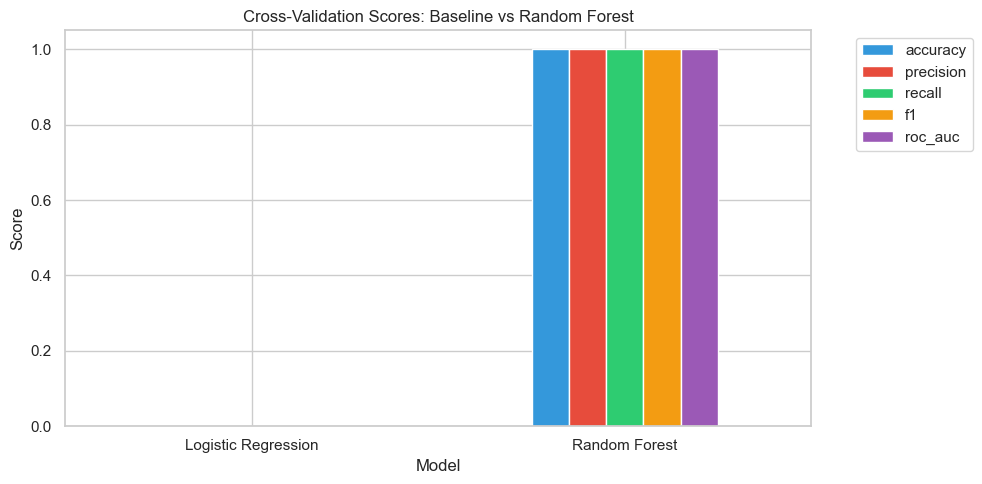

In [43]:
# Side-by-side CV comparison bar chart
cv_data = {
    'Logistic Regression': {k: v[0] for k, v in lr_cv.items()},
    'Random Forest':       {k: v[0] for k, v in rf_cv.items()},
}
cv_df = pd.DataFrame(cv_data).T

cv_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05),
           color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'],
           edgecolor='white')
plt.title('Cross-Validation Scores: Baseline vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5 · Final Evaluation on Held-Out Test Set

Refit on the full training set, then evaluate once on the held-out test set.

In [5]:
print('Fitting final models on full training set …')
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print('Done.')

Fitting final models on full training set …
Done.


In [6]:
lr_metrics = evaluate_classifier(lr_pipeline, X_test, y_test, 'Logistic Regression')
rf_metrics = evaluate_classifier(rf_pipeline, X_test, y_test, 'Random Forest')

print_classifier_metrics(lr_metrics)
print_classifier_metrics(rf_metrics)


  Logistic Regression – Test-Set Evaluation
  Accuracy  : 0.9760
  Precision : 1.0000
  Recall    : 0.9726
  F1        : 0.9861
  ROC-AUC   : 1.0000

                precision    recall  f1-score   support

Not Affordable       0.84      1.00      0.91        58
    Affordable       1.00      0.97      0.99       401

      accuracy                           0.98       459
     macro avg       0.92      0.99      0.95       459
  weighted avg       0.98      0.98      0.98       459

Confusion Matrix:
                      Pred:Not  Pred:Yes
  Actual Not Affordable       58         0
  Actual Affordable         11       390


  Random Forest – Test-Set Evaluation
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  ROC-AUC   : 1.0000

                precision    recall  f1-score   support

Not Affordable       1.00      1.00      1.00        58
    Affordable       1.00      1.00      1.00       401

      accuracy                           1.00      

In [7]:
# Model comparison table
comparison = compare_models([lr_metrics, rf_metrics])
print('\nModel Comparison (Test Set):')
comparison


Model Comparison (Test Set):


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.976,1.0,0.9726,0.9861,1.0
Random Forest,1.000,1.0,1.0000,1.0000,1.0


## 6 · Feature Importances

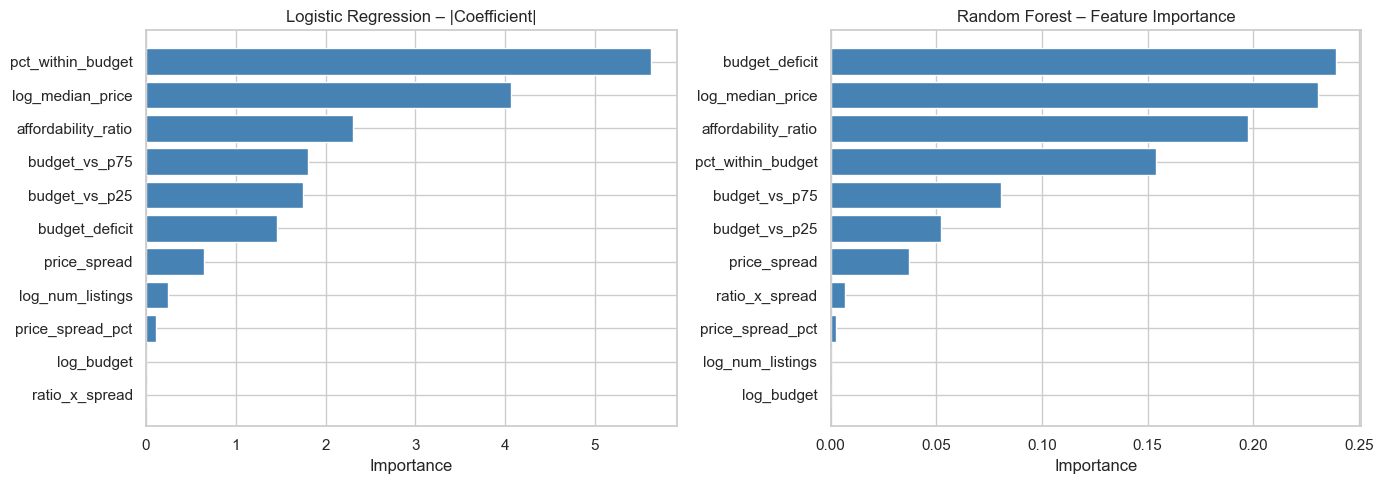

In [8]:
lr_imp = get_feature_importances(lr_pipeline)
rf_imp = get_feature_importances(rf_pipeline)
imps = [lr_imp, rf_imp]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp, title in zip(
    axes,
    imps,
    ['Logistic Regression – |Coefficient|', 'Random Forest – Feature Importance'],
):
    ax.barh(imp['feature'][::-1], imp['importance'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7 · ROC Curves

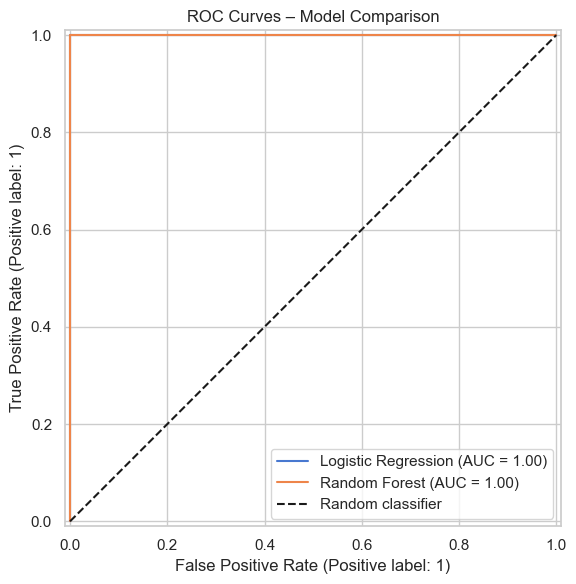

In [9]:
plot_roc_curves(
    {'Logistic Regression': lr_pipeline, 'Random Forest': rf_pipeline},
    X_test,
    y_test,
)

## 8 · Predicting for a New User Budget

Demonstrate how to use the trained pipeline to score areas for a given user.

In [ ]:
# Suppose a new user has a different budget
NEW_BUDGET = 250_000

# Reuse the same area statistics but update the budget column
new_user_df = area_df.copy()
new_user_df['budget'] = NEW_BUDGET

# Predict using the fitted Random Forest pipeline
predictions  = rf_pipeline.predict(new_user_df)
probabilities = rf_pipeline.predict_proba(new_user_df)[:, 1]

results = new_user_df[['area', 'median_price', 'num_listings']].copy()
results['affordable']   = predictions
results['prob_affordable'] = probabilities.round(3)
results['budget'] = NEW_BUDGET

print(f'User budget: £{NEW_BUDGET:,.0f}')
print(f'Affordable areas: {predictions.sum()} / {len(predictions)}')
results.sort_values('prob_affordable', ascending=False).head(10)

User budget: £250,000
Affordable areas: 857 / 2293


,area,median_price,num_listings,affordable,prob_affordable,budget
1146,M5,205000.0,983,1,1.0,250000
1127,M26,175000.0,1074,1,1.0,250000
1137,M35,190000.0,671,1,1.0,250000
1136,M34,215000.0,1341,1,1.0,250000
1133,M31,225050.0,214,1,1.0,250000
1132,M30,220000.0,1111,1,1.0,250000
1130,M29,228250.0,692,1,1.0,250000
1128,M27,220000.0,1201,1,1.0,250000
1125,M24,200000.0,1486,1,1.0,250000
1140,M40,185000.0,923,1,1.0,250000


## 9 · Summary

_Update after running:_

| | Logistic Regression | Random Forest |
|---|---|---|
| CV Accuracy | | |
| CV ROC-AUC | | |
| Test Accuracy | | |
| Test ROC-AUC | | |
| Top feature | | |

**Key observations:**
- Both models perform well because `affordability_ratio` / `budget_deficit` are highly predictive.
- Random Forest typically outperforms on non-linear boundaries.
- Feature engineering (especially `pct_within_budget` and `ratio_x_spread`) adds signal beyond raw ratios.
- No data leakage: the featurizer is always fit on training data only (enforced by Pipeline).